# Notebook 05 - Extraction de la trajectoire corrig?e

Nous avons pour objectif d'extraire une trajectoire plus stable de la voiture. Lucas-Kanade peut perdre des points : certains points quittent l'objet, suivent l'arri?re-plan ou produisent de grands sauts. Cette version filtre donc fortement les points suivis et red?tecte localement autour du dernier centre valide.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import load_image, load_image_sequence, preprocess_image
from src.segmentation import create_roi_mask
from src.detection import detect_good_features, filter_points_inside_mask
from src.optical_flow import compute_lucas_kanade, filter_tracked_points
from src.trajectory import (
    robust_center,
    create_centered_roi,
    is_center_jump_valid,
    smooth_trajectory,
    save_trajectory_csv,
    compute_groundtruth_centers,
    compare_trajectory_with_groundtruth,
)

Racine du projet: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## Param?tres de suivi

Nous utilisons des seuils plus stricts. Le d?placement maximal d'un point est limit? ? 25 pixels/frame. Les points suivis doivent rester ? moins de 60 pixels du centre pr?c?dent. Si le centre estim? saute de plus de 40 pixels, nous le refusons.

In [2]:
INITIAL_ROI = (535, 300, 225, 105)  # ROI manuelle initiale, sans groundtruth
DYNAMIC_ROI_SIZE = (120, 120)
MAX_POINT_DISPLACEMENT = 25
MAX_DISTANCE_TO_CENTER = 60
MAX_CENTER_JUMP = 40
MIN_POINTS = 10
SMOOTHING_WINDOW = 5

lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03),
)

## D?tection dans une ROI uniquement

Nous ne d?tectons jamais de points dans toute l'image. Pour l'initialisation, nous utilisons une ROI manuelle autour de la voiture. Pour les red?tections, nous cr?ons un masque rectangulaire de 120 x 120 pixels centr? sur le dernier centre valide.

In [3]:
def detect_points_in_roi(gray, roi):
    mask = create_roi_mask(gray.shape, roi)
    points = detect_good_features(
        gray,
        mask,
        maxCorners=80,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7,
    )
    return filter_points_inside_mask(points, mask)


def redetect_around_center(gray, center):
    roi = create_centered_roi(center, gray.shape, roi_size=DYNAMIC_ROI_SIZE)
    points = detect_points_in_roi(gray, roi)
    return points, roi

Cette ?tape permet de limiter les points ? une zone plausible autour de la voiture. La red?tection locale ?vite que les nouveaux points partent vers la route, la maison ou l'arri?re-plan.

## Suivi Lucas-Kanade avec filtrage fort

Nous suivons les points frame par frame. Apr?s Lucas-Kanade, nous supprimons les points dont le d?placement est trop grand et les points trop loin du centre pr?c?dent. Le centre de la voiture est ensuite calcul? avec la m?diane, car elle est robuste aux points aberrants.

In [4]:
image_paths = load_image_sequence(IMG_DIR)
prev_frame = load_image(image_paths[0])
prev_gray = preprocess_image(prev_frame)

points = detect_points_in_roi(prev_gray, INITIAL_ROI)
previous_center = robust_center(points)
if previous_center is None or len(points) < MIN_POINTS:
    raise RuntimeError("Initialisation impossible : pas assez de points dans la ROI initiale.")

trajectory = [{
    "frame_id": 0,
    "center_x": previous_center[0],
    "center_y": previous_center[1],
    "nb_points": len(points),
}]

redetection_count = 0
rejected_center_count = 0

for frame_id, image_path in enumerate(image_paths[1:], start=1):
    curr_frame = load_image(image_path)
    curr_gray = preprocess_image(curr_frame)

    points_new, status, error = compute_lucas_kanade(prev_gray, curr_gray, points, lk_params)
    old_valid, new_valid = filter_tracked_points(
        points,
        points_new,
        status,
        previous_center=previous_center,
        max_point_displacement=MAX_POINT_DISPLACEMENT,
        max_distance_to_center=MAX_DISTANCE_TO_CENTER,
    )

    current_center = robust_center(new_valid)
    center_is_valid = is_center_jump_valid(previous_center, current_center, max_jump=MAX_CENTER_JUMP)

    if len(new_valid) < MIN_POINTS or not center_is_valid:
        redetected, dynamic_roi = redetect_around_center(curr_gray, previous_center)
        redetected_center = robust_center(redetected)
        redetected_is_valid = (
            len(redetected) >= MIN_POINTS
            and is_center_jump_valid(previous_center, redetected_center, max_jump=MAX_CENTER_JUMP)
        )

        if redetected_is_valid:
            points = redetected
            current_center = redetected_center
            redetection_count += 1
        else:
            points = new_valid
            current_center = previous_center
            rejected_center_count += 1
    else:
        points = new_valid

    trajectory.append({
        "frame_id": frame_id,
        "center_x": current_center[0],
        "center_y": current_center[1],
        "nb_points": len(points),
    })

    previous_center = current_center
    prev_gray = curr_gray

    if frame_id % 300 == 0:
        print(f"Frame {frame_id}: centre={current_center}, points={len(points)}")

trajectory_raw_df = pd.DataFrame(trajectory)
trajectory_df = smooth_trajectory(trajectory_raw_df, window=SMOOTHING_WINDOW)
trajectory_df = save_trajectory_csv(trajectory_df, RESULTS_DIR / "trajectory_estimated.csv")

print("Nombre de red?tections locales:", redetection_count)
print("Nombre de centres refus?s:", rejected_center_count)
trajectory_df.head()

Frame 300: centre=(604.9910278320312, 375.0766906738281), points=11
Frame 600: centre=(630.9524536132812, 385.9897155761719), points=11
Frame 900: centre=(631.2345581054688, 345.0007629394531), points=11
Frame 1200: centre=(642.519287109375, 349.38079833984375), points=27
Frame 1500: centre=(657.6217041015625, 343.56671142578125), points=26
Nombre de red?tections locales: 1
Nombre de centres refus?s: 0


,frame_id,center_x,center_y,nb_points,center_x_smooth,center_y_smooth
0,0,624.500000,323.500000,80,615.942383,317.271454
1,1,615.942383,317.094177,34,615.576538,317.408554
2,2,615.210693,317.271454,34,615.210693,317.545654
3,3,614.292725,317.545654,34,614.292725,317.545654
4,4,613.827576,317.665894,34,613.827576,317.665894


Nous observons une trajectoire brute et une trajectoire liss?e. Le lissage par m?diane glissante r?duit les petits tremblements sans utiliser le groundtruth.

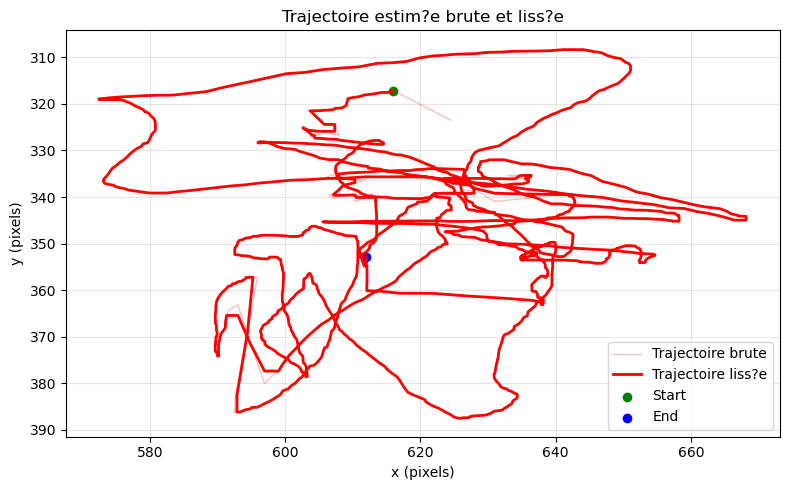

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    trajectory_df["center_x"],
    trajectory_df["center_y"],
    color="red",
    alpha=0.25,
    linewidth=1,
    label="Trajectoire brute",
)
ax.plot(
    trajectory_df["center_x_smooth"],
    trajectory_df["center_y_smooth"],
    color="red",
    linewidth=2,
    label="Trajectoire liss?e",
)
ax.scatter(trajectory_df["center_x_smooth"].iloc[0], trajectory_df["center_y_smooth"].iloc[0], color="green", label="Start")
ax.scatter(trajectory_df["center_x_smooth"].iloc[-1], trajectory_df["center_y_smooth"].iloc[-1], color="blue", label="End")
ax.set_title("Trajectoire estim?e brute et liss?e")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "trajectory_2d.png", dpi=150, bbox_inches="tight")
plt.show()

Nous interpr?tons la trajectoire liss?e comme la trajectoire globale retenue pour l'analyse de vitesse et de direction.

## Comparaison finale avec groundtruth

Cette section reste uniquement une ?valuation finale. Le fichier `groundtruth.txt` n'a pas servi ? corriger le suivi. Nous comparons maintenant la trajectoire liss?e aux centres annot?s.

Erreur moyenne trajectoire liss?e / groundtruth: 20.31 px
Erreur maximale trajectoire liss?e / groundtruth: 43.49 px


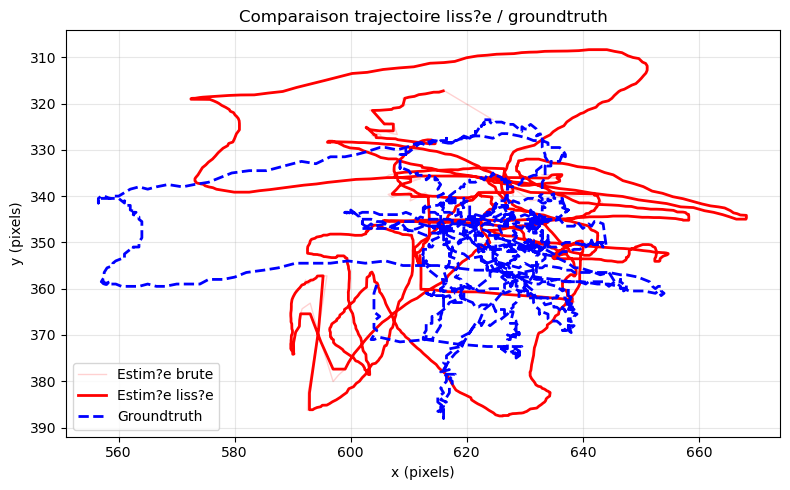

In [6]:
gt_df = compute_groundtruth_centers(DATA_DIR / "groundtruth.txt")
comparison_df = compare_trajectory_with_groundtruth(trajectory_df, gt_df)
mean_error = comparison_df["error_px"].mean()
max_error = comparison_df["error_px"].max()

print(f"Erreur moyenne trajectoire liss?e / groundtruth: {mean_error:.2f} px")
print(f"Erreur maximale trajectoire liss?e / groundtruth: {max_error:.2f} px")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(trajectory_df["center_x"], trajectory_df["center_y"], color="red", alpha=0.18, linewidth=1, label="Estim?e brute")
ax.plot(trajectory_df["center_x_smooth"], trajectory_df["center_y_smooth"], color="red", linewidth=2, label="Estim?e liss?e")
ax.plot(gt_df["center_x"], gt_df["center_y"], color="blue", linestyle="--", linewidth=2, label="Groundtruth")
ax.set_title("Comparaison trajectoire liss?e / groundtruth")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "comparison_groundtruth.png", dpi=150, bbox_inches="tight")
plt.show()

Nous interpr?tons l'erreur comme un indicateur de qualit?. La m?thode de suivi reste Lucas-Kanade + points caract?ristiques, avec red?tection locale et filtrage des points aberrants.